# 02a — iPinYou EDA: what this data actually is

A narrated exploration of the iPinYou RTB dataset, written for a reader who has never touched
it. The fitting notebook (`02_ipinyou.ipynb`) extracts parameters; this one establishes the
foundational truths those extractions rest on — mechanics, schema, semantics, structure,
quirks, and what any of it means for a lead marketplace. Read-only: no artifacts, no mutations
(spec Section 0, v0.4).

Provenance: HD — built to the human's direction that foundational understanding always be
surfaced (P-006, INT-012).

## The one mental model that unlocks this dataset

**This is not "the auction market's data." It is one bidder's diary.** iPinYou was a Chinese
*demand-side platform* (DSP): a company that bids in real-time advertising auctions on behalf
of advertiser clients. Every row traces this flow:

1. A user loads a webpage; the page has an empty ad slot.
2. The publisher's **ad exchange** broadcasts a *bid request* ("user X, slot 300x250 on domain
   Y, reserve price 80") to many DSPs simultaneously — iPinYou is just one of them.
3. iPinYou picks **one** of its advertiser clients and submits **one bid** (a `bid` log row).
4. The exchange runs a **second-price auction** across all DSPs: highest bid wins but pays the
   *second-highest* bid (or the reserve, if that is higher).
5. If iPinYou won, the ad shows and an `imp` row is logged — with `paying_price`, the amount
   actually paid, which *is* the best rival bid. If it lost: nothing beyond the bid log. The
   market price of a lost auction is never observed.
6. A later click becomes a `clk` row; a conversion on the advertiser's site a `conv` row —
   all joined by `bid_id`.

So the four log types are one funnel — `bid` (we bid) -> `imp` (we won) -> `clk` (they
clicked) -> `conv` (they converted) — and everything you cannot see (rivals' bids, lost
auctions' prices) is exactly what a real marketplace participant cannot see either.


In [1]:
# Setup. This notebook profiles one full day per season at full schema (the structure is
# identical across days) plus funnel and advertiser aggregates across the whole D4 sample.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "pyproject.toml").exists()
RAW = ROOT / "data" / "raw" / "ipinyou"
DAYS = {"training2nd": ["20130608", "20130610", "20130612"],
        "training3rd": ["20131019", "20131020", "20131021", "20131022", "20131023"]}

# Column names for the 24-field imp/clk/conv logs, verified against the raw files and the
# dataset README (the 21-field bid logs drop log_type, paying_price, key_page_url).
COLS = ["bid_id", "timestamp", "log_type", "ipinyou_id", "user_agent", "ip", "region", "city",
        "ad_exchange", "domain", "url", "anonymous_url_id", "ad_slot_id", "ad_slot_width",
        "ad_slot_height", "ad_slot_visibility", "ad_slot_format", "ad_slot_floor_price",
        "creative_id", "bidding_price", "paying_price", "key_page_url", "advertiser_id",
        "user_tags"]

def load_imp_day(season, day):
    return pd.read_csv(RAW / season / f"imp.{day}.txt.bz2", sep="\t", header=None,
                       names=COLS, compression="bz2", quoting=3, na_values=["null"])

d2 = load_imp_day("training2nd", "20130608")
d3 = load_imp_day("training3rd", "20131021")
both = pd.concat([d2.assign(season=2), d3.assign(season=3)], ignore_index=True)
print(f"profiling days: season 2 = {len(d2):,} rows, season 3 = {len(d3):,} rows")


profiling days: season 2 = 1,634,830 rows, season 3 = 848,740 rows


## 1. The funnel, end to end

Bid volume comes from the fitting notebook's artifact (`auction_landscape.json` metadata) —
the bid logs are 1.2 GB of bz2 and were already counted there; re-parsing them here would
re-derive an established fact (spec Section 0).


In [2]:
AL = json.loads((ROOT / "simulation" / "params" / "auction_landscape.json").read_text())
n_bids = AL["metadata"]["sources"]["bids"]
n_imps = AL["metadata"]["sources"]["impressions"]
n_clks = AL["metadata"]["sources"]["clicks"]
n_convs = AL["metadata"]["sources"]["conversions"]
funnel = pd.DataFrame({
    "stage": ["bids submitted", "impressions won", "clicks", "conversions"],
    "count": [n_bids, n_imps, n_clks, n_convs],
    "rate_from_prior": [np.nan, n_imps/n_bids, n_clks/n_imps, n_convs/n_clks],
})
print(funnel.to_string(index=False))
print(f"\nDisplay advertising's funnel in one line: win rate {n_imps/n_bids:.1%}, "
      f"CTR {n_clks/n_imps:.3%}, click-to-conversion {n_convs/n_clks:.1%}.")


          stage    count  rate_from_prior
 bids submitted 20611692              NaN
impressions won  7426211         0.360291
         clicks     6329         0.000852
    conversions      847         0.133828

Display advertising's funnel in one line: win rate 36.0%, CTR 0.085%, click-to-conversion 13.4%.


## 2. Sample rows

Four impressions, hashes truncated for readability. Reading the first row: at 00:13 local
time, a user in region 238 loaded a news page; exchange 3 offered a 960x90 banner with a
reserve of 50; iPinYou bid 300 for advertiser 3386, won, and paid 86 — meaning the best rival
bid was 86. A row where `paying_price` equals the floor is a *reserve-bound* win: no rival
cleared the reserve.


In [3]:
smp = d2.sample(4, random_state=7).copy()
for c in ("bid_id", "ipinyou_id", "user_agent", "domain", "url", "creative_id",
          "key_page_url", "ad_slot_id"):
    smp[c] = smp[c].astype(str).str.slice(0, 16)
smp.drop(columns=["log_type", "anonymous_url_id"])


,bid_id,timestamp,ipinyou_id,user_agent,ip,region,city,ad_exchange,domain,url,...,ad_slot_height,ad_slot_visibility,ad_slot_format,ad_slot_floor_price,creative_id,bidding_price,paying_price,key_page_url,advertiser_id,user_tags
63284,7124cc5f5cf2117e,20130608001306551,Vh1LVxu3P99sDoL,Mozilla/4.0 (com,123.79.128.*,238,246,3,5F1RQS9rg5scFsf,bfa000ed663f4997,...,90,0,0,50,011c1a3d4d3f089a,300,86,43f4a37f42a7c5e6,3386,"10083,14273,10006,10063,10075,10052,10079,1005..."
921732,7052830d40615a56,20130608155632878,VhkxPv1l3TcfDfl,Mozilla/5.0 (Win,183.93.104.*,183,192,3,5F1RQS9rg5scFsf,36059b229c8e4cbc,...,250,0,0,80,44966cc8da1ed40c,300,81,43f4a37f42a7c5e6,3386,NaN
65797,aeef942351e2ad06,20130608001608385,Z0TH1kkxOocy3YC,Mozilla/5.0 (Win,218.72.174.*,94,101,2,DFpETuFygZl7gspy,e3775fe40d5125bd,...,600,2,0,39,bc27493ad2351e25,249,154,a8f8eeaae5c1e2e9,3476,"10052,10083,10110"
863320,e7be731902eb083b,20130608151927473,VhkxPwN3P8nIJbj,Mozilla/5.0 (com,61.138.125.*,27,29,3,ersbQv1RdoTy1m58,70a7edf3fbfc6674,...,90,0,0,20,832b91d59d0cb573,300,20,bebefa5efe83beee,1458,"10083,10110"


## 3. Data dictionary

Distinct and null counts computed on the season-2 profiling day (1.63M rows). Definitions
follow the dataset README and the iPinYou benchmark literature; entries marked "(assumption)"
are documented conventions rather than facts printed in the data itself.


In [4]:
DEFS = {
    "bid_id": "Unique id of the bid/auction event; the join key across bid -> imp -> clk -> conv",
    "timestamp": "Event time, yyyyMMddHHmmssSSS (millisecond precision, local time)",
    "log_type": "1 = impression, 2 = click, 3 = conversion (constant within each file)",
    "ipinyou_id": "iPinYou's user cookie id — the 'person' identifier",
    "user_agent": "Browser user-agent string",
    "ip": "User IP, last octet masked (123.79.128.*) — built-in anonymization",
    "region": "Province-level geo code; lookup in region.en.txt (1=beijing, 2=tianjin, ...)",
    "city": "City code (city.en.txt); nested inside region — see collinearity section",
    "ad_exchange": "Which exchange sent the bid request",
    "domain": "Hashed publisher site",
    "url": "Hashed page URL",
    "anonymous_url_id": "Set only when the exchange hides the URL; empty in this day",
    "ad_slot_id": "Publisher's slot identifier (mix of names and numeric ids)",
    "ad_slot_width": "Slot width in px (standard IAB sizes)",
    "ad_slot_height": "Slot height in px",
    "ad_slot_visibility": "Fold position: 0 unknown, 1 above fold, 2 below fold, 255 other (assumption)",
    "ad_slot_format": "0 fixed, 1 popup, 5 other (assumption)",
    "ad_slot_floor_price": "Publisher's reserve price for the slot; 0 = no reserve",
    "creative_id": "The specific ad shown; nested inside advertiser",
    "bidding_price": "iPinYou's submitted bid — near-constant by competition design (Section 4)",
    "paying_price": "THE money column: second-price paid = highest rival bid (or the floor)",
    "key_page_url": "Advertiser landing/conversion page (hashed); nested inside advertiser",
    "advertiser_id": "Which client iPinYou bid for (5 campaigns per season)",
    "user_tags": "Comma-separated iPinYou audience-segment ids (seasons 2-3 only)",
}
dictionary = pd.DataFrame(
    [(c, str(d2[c].dtype), d2[c].nunique(), int(d2[c].isna().sum()),
      round(d2[c].isna().mean() * 100, 2), DEFS[c]) for c in COLS],
    columns=["column", "dtype", "distinct", "nulls", "null_pct", "definition"])
pd.set_option("display.max_colwidth", 95)
dictionary


,column,dtype,distinct,nulls,null_pct,definition
0,bid_id,str,1629308,0,0.00,Unique id of the bid/auction event; the join key across bid -> imp -> clk -> conv
1,timestamp,int64,1432298,0,0.00,"Event time, yyyyMMddHHmmssSSS (millisecond precision, local time)"
2,log_type,int64,1,0,0.00,"1 = impression, 2 = click, 3 = conversion (constant within each file)"
3,ipinyou_id,str,1477684,0,0.00,iPinYou's user cookie id — the 'person' identifier
4,user_agent,str,107941,185,0.01,Browser user-agent string
5,ip,str,424297,0,0.00,"User IP, last octet masked (123.79.128.*) — built-in anonymization"
6,region,int64,35,0,0.00,"Province-level geo code; lookup in region.en.txt (1=beijing, 2=tianjin, ...)"
7,city,int64,370,0,0.00,City code (city.en.txt); nested inside region — see collinearity section
8,ad_exchange,int64,3,0,0.00,Which exchange sent the bid request
9,domain,str,12092,85839,5.25,Hashed publisher site


## 4. Prices: units, distributions, and two crucial caveats

**Units (declared assumption):** prices are RMB per CPM (per thousand impressions), the
convention documented in the iPinYou benchmark literature — `paying_price` 86 means about
0.086 RMB for this single impression. Nothing downstream depends on the unit: the fitting
notebook transfers only the distribution *shape* and rescales levels to the C1 dollar anchors.


In [5]:
print(both.groupby("season")[["ad_slot_floor_price", "bidding_price", "paying_price"]]
      .describe(percentiles=[.25, .5, .75, .99]).round(1).to_string())
print()

# Caveat 1 — the fixed-bid strategy: bidding_price is near-constant per campaign.
fixed = both.groupby(["season", "advertiser_id"])["bidding_price"].agg(
    ["nunique", "min", "max", "count"])
print("bidding_price cardinality per campaign (the competition's fixed-bid strategy):")
print(fixed.to_string())
print("\nThe README discloses a fixed, deliberately HIGH bidding strategy — chosen to win"
      "\noften and observe many paying prices. Consequences: bidding_price carries almost no"
      "\ninformation, and the win rate is an artifact of that strategy, not organic skill.")

# Caveat 2 — a known logging quirk: paying > bidding is mechanically impossible in a clean
# second-price auction, yet occurs in ~1% of rows. We treat paying_price as authoritative.
n_bad = int((both["paying_price"] > both["bidding_price"]).sum())
print(f"\npaying_price > bidding_price rows: {n_bad:,} ({n_bad/len(both):.2%}) — known "
      f"dataset logging artifact; paying_price treated as authoritative.")

floored = both[both["ad_slot_floor_price"] > 0]
at_floor = (floored["paying_price"] == floored["ad_slot_floor_price"]).mean()
print(f"rows with a reserve set: {len(floored)/len(both):.1%}; of those, paid exactly the "
      f"reserve: {at_floor:.1%} — reserve-bound sales are real in the source data too.")


       ad_slot_floor_price                                                bidding_price                                                        paying_price                                                  
                     count  mean   std  min  25%  50%   75%    99%    max         count   mean   std    min    25%    50%    75%    99%    max        count  mean   std  min   25%   50%    75%    99%    max
season                                                                                                                                                                                                       
2                1634830.0  28.2  37.7  0.0  0.0  5.0  70.0  162.0  299.0     1634830.0  269.1  30.7  227.0  238.0  254.0  300.0  300.0  300.0    1634830.0  81.1  60.2  0.0  39.0  70.0   95.0  263.0  300.0
3                 848740.0  23.5  38.0  0.0  0.0  5.0  30.0  180.0  276.0      848740.0  289.7   7.4  277.0  277.0  294.0  294.0  294.0  294.0     848740.0  90.1  73.9  1.0  31

rows with a reserve set: 67.7%; of those, paid exactly the reserve: 28.9% — reserve-bound sales are real in the source data too.


## 5. Collinearity — mostly *structural*, not statistical

The interesting dependence is hierarchical nesting (perfect categorical collinearity):
a model that includes the child column implicitly contains the parent.


In [6]:
checks = [
    ("city -> region", (d2.groupby("city")["region"].nunique() > 1).sum(), d2["city"].nunique()),
    ("creative_id -> advertiser_id", (d2.groupby("creative_id")["advertiser_id"].nunique() > 1).sum(),
     d2["creative_id"].nunique()),
    ("key_page_url -> advertiser_id", (d2.groupby("key_page_url")["advertiser_id"].nunique() > 1).sum(),
     d2["key_page_url"].nunique()),
    ("ad_slot_id -> domain", (d2.groupby("ad_slot_id")["domain"].nunique() > 1).sum(),
     d2["ad_slot_id"].nunique()),
]
print("functional-dependency violations (0 = perfectly nested):")
for name, viol, total in checks:
    print(f"  {name}: {viol} of {total}")

num = d2[["ad_slot_width", "ad_slot_height", "ad_slot_floor_price",
          "bidding_price", "paying_price"]].assign(
    slot_area=d2["ad_slot_width"] * d2["ad_slot_height"])
print("\nPearson correlations:")
print(num.corr().round(3).to_string())


functional-dependency violations (0 = perfectly nested):
  city -> region: 0 of 370
  creative_id -> advertiser_id: 0 of 49
  key_page_url -> advertiser_id: 0 of 16
  ad_slot_id -> domain: 2226 of 38405

Pearson correlations:
                     ad_slot_width  ad_slot_height  ad_slot_floor_price  bidding_price  paying_price  slot_area
ad_slot_width                1.000          -0.786                0.496          0.082        -0.082      0.268
ad_slot_height              -0.786           1.000               -0.289         -0.035         0.059      0.235
ad_slot_floor_price          0.496          -0.289                1.000          0.118         0.120      0.240
bidding_price                0.082          -0.035                0.118          1.000        -0.096      0.023
paying_price                -0.082           0.059                0.120         -0.096         1.000      0.012
slot_area                    0.268           0.235                0.240          0.023         0.012  

Reading the structure:

- **`city` -> `region` and `creative`/`key_page_url` -> `advertiser` are perfectly nested**
  (zero violations). Never feed both levels to a model untransformed. `ad_slot_id` -> `domain`
  is *near*-nested — the violations are mostly generic slot names ("300x250") reused across
  sites.
- **`width` vs `height` at -0.79**: banner geometry — wide slots are short, tall slots are
  narrow. These are discrete IAB shapes, not a continuum.
- **`paying_price` is nearly uncorrelated with every observable** (all |r| < 0.13). Price
  variation lives *within* slot/context combinations — i.e., in the unobserved competing
  bids. This emptiness is a finding: observable features explain little of price, which is
  also why the CTR-proxy elasticity regression in the fitting notebook found only a weak
  (and negative — C9) slope.


## 6. Advertisers: how many, and how many per auction

Volumes below span the full 8-day D4 sample. The vertical mapping comes from the iPinYou
benchmark paper (Zhang, Yuan, Wang 2014): season 2 — 1458 local e-commerce, 3358 software,
3386 international e-commerce, 3427 oil, 3476 tires; season 3 — 2259 milk powder, 2261
telecom, 2821 footwear, 2997 mobile e-commerce. Seasons 2-3 contain nine advertisers total;
**eight appear in our sampled days** (2261 ran only on days outside the D4 sample).


In [7]:
VERTICALS = {1458: "local e-commerce", 3358: "software", 3386: "international e-commerce",
             3427: "oil", 3476: "tires", 2259: "milk powder", 2261: "telecom",
             2821: "footwear", 2997: "mobile e-commerce"}
rows = []
for season, days in DAYS.items():
    per_adv = {}
    for day in days:
        vc = pd.read_csv(RAW / season / f"imp.{day}.txt.bz2", sep="\t", header=None,
                         usecols=[22], compression="bz2", quoting=3)[22].value_counts()
        for adv, n in vc.items():
            per_adv.setdefault(adv, {})[day] = int(n)
    for adv, by_day in sorted(per_adv.items()):
        rows.append((season, adv, VERTICALS.get(adv, "?"), sum(by_day.values()),
                     f"{len(by_day)}/{len(days)}"))
adv_table = pd.DataFrame(rows, columns=["season", "advertiser", "vertical",
                                         "impressions_won", "days_active"])
print(adv_table.to_string(index=False))


     season  advertiser                 vertical  impressions_won days_active
training2nd        1458         local e-commerce          1295537         3/3
training2nd        3358                 software           974768         3/3
training2nd        3386 international e-commerce          1160030         3/3
training2nd        3427                      oil          1114016         3/3
training2nd        3476                    tires           668187         3/3
training3rd        2259              milk powder           835556         4/5
training3rd        2821                 footwear          1322561         3/5
training3rd        2997        mobile e-commerce            55556         1/5


In [8]:
# How many advertisers compete per auction, from this dataset's viewpoint? Exactly one —
# iPinYou selects a single client per bid request. Verify: among bid_ids that appear on
# multiple impression rows, how many involve more than one advertiser?
dup = d2[d2.duplicated("bid_id", keep=False)]
g = dup.groupby("bid_id")["advertiser_id"].nunique()
print(f"bid_ids with multiple imp rows: {dup['bid_id'].nunique():,} "
      f"({len(dup)/len(d2):.2%} of rows) — re-logged events")
print(f"share of those involving >1 advertiser: {(g > 1).mean():.3f}")
print("\nThe advertisers in this dataset never compete with each other in a recorded "
      "auction.\nTheir competition is invisible external bidders, observable only through "
      "paying_price\n(when iPinYou wins) or silence (when it loses).")


bid_ids with multiple imp rows: 5,252 (0.66% of rows) — re-logged events
share of those involving >1 advertiser: 0.000

The advertisers in this dataset never compete with each other in a recorded auction.
Their competition is invisible external bidders, observable only through paying_price
(when iPinYou wins) or silence (when it loses).


## 7. Exhibits


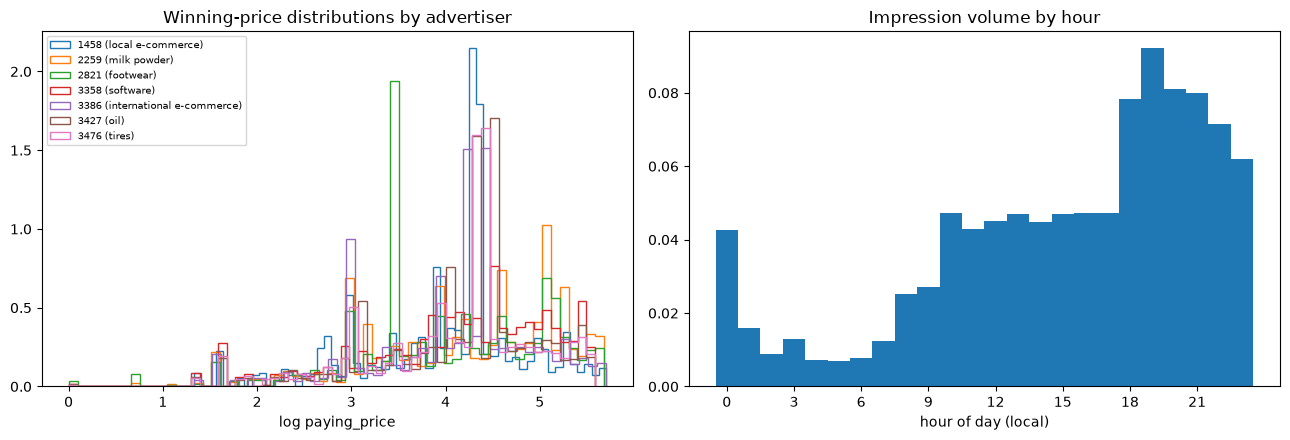

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Price distributions by advertiser: location and scale differ by campaign — this is why the
# fitting notebook standardizes per advertiser before pooling the shape (C10).
for adv, grp in both[both["paying_price"] > 0].groupby("advertiser_id"):
    axes[0].hist(np.log(grp["paying_price"]), bins=60, density=True, histtype="step",
                 label=f"{adv} ({VERTICALS.get(adv, '?')})")
axes[0].set(xlabel="log paying_price", title="Winning-price distributions by advertiser")
axes[0].legend(fontsize=7)

# Hourly rhythm: timestamps carry a strong diurnal cycle — real human traffic.
hours = (both["timestamp"] // 10**7 % 100).astype(int)
axes[1].hist(hours, bins=np.arange(25) - 0.5, density=True)
axes[1].set(xlabel="hour of day (local)", title="Impression volume by hour",
            xticks=range(0, 24, 3))
fig.tight_layout()
plt.show()


## 8. Business implications for Tributary — and the declared assumptions

Why this dataset, for a lead marketplace:

- **Censoring is the core analytics problem.** The market price is observed only on wins;
  losses reveal only a bound. Structurally identical to a lead marketplace, where an unsold
  lead never reveals what a buyer would have paid. This trains Model 2's censored-price
  machinery on honest structure.
- **Partial observability is the realistic condition.** No participant sees rivals' bids.
  The fitting notebook's bidders-per-auction and participation parameters are *declared
  analogs* derived from win rates — recorded in the artifact — because the truth is
  unobservable even here.
- **Second-price with reserves produces reserve-bound sales** (a fifth to a third of floored
  wins here; ~93% in the calibrated waterfall, where competition is thinner). Reserve
  optimization — Model 3 — is exactly the lever trading sell-through against price.

Declared assumptions made in this analysis, all called out where used:

1. Price unit is RMB per CPM (documented convention; only the shape transfers regardless).
2. Visibility/format code meanings follow the benchmark literature's decoding.
3. `paying_price` is authoritative where it exceeds `bidding_price` (~1% known logging quirk).
4. The advertiser-vertical mapping follows the benchmark paper.
5. Win rate reflects the competition's fixed-bid strategy, not organic bidding — so every
   parameter derived from it (participation, bidders-per-auction) is an analog, not a
   measurement (see C9 and the artifact's participation.assumption field).

Related: `02_ipinyou.ipynb` (the fits), `simulation/params/auction_landscape.json` (the
artifact), decisions C1, C2, C9, C10 in `meta/logs/decisions.md`.
